In [ ]:
!wget https://github.com/markovka17/dla/raw/refs/heads/2024/week03/mystery_records.pickle
!wget https://github.com/markovka17/dla/raw/refs/heads/2024/week03/LJ001-0001.wav
!wget https://github.com/markovka17/dla/raw/refs/heads/2024/week03/lj_batch.pickle
!wget https://github.com/markovka17/dla/raw/refs/heads/2024/week03/h001_Bedroom_65.wav

Based on https://github.com/markovka17/dla/

# Speech Augmentations

In this seminar, we will learn basic augmentations for speech.

    1) Gaussian Noise
    2) Time Stretching
    3) Pitch Shifting
    4) Volume
    5) Impulse Response
    6) Add Noise on Background
    7) SpecAug (Time/Freq masking, Cutout)

Also pay attention on `SpeechBrain` library which contain a lot of useful stuff including [speech augumentation](https://speechbrain.readthedocs.io/en/latest/API/speechbrain.processing.speech_augmentation.html#speechbrain.processing.speech_augmentation.AddBabble)

In [ ]:
!pip install torchcodec

---

In [ ]:
from IPython import display
from matplotlib import pyplot as plt

import torch
import torch.nn.functional as F
from torch import nn
from torch import distributions
import torchaudio

import librosa

In [ ]:
def visualize_audio(wav: torch.Tensor, sr: int = 22050, normalize=False):
    # Average all channels
    if wav.dim() == 2:
        # Any to mono audio convertion
        wav = wav.mean(dim=0)

    plt.figure(figsize=(20, 5))
    plt.plot(wav, alpha=.7, c='green')
    plt.grid()
    plt.xlabel('Time', size=20)
    plt.ylabel('Amplitude', size=20)
    plt.show()

    display.display(display.Audio(wav, rate=sr, normalize=normalize))

In [ ]:
wav, sr = torchaudio.load('LJ001-0001.wav')

In [ ]:
sr

22050

# Ground Truth

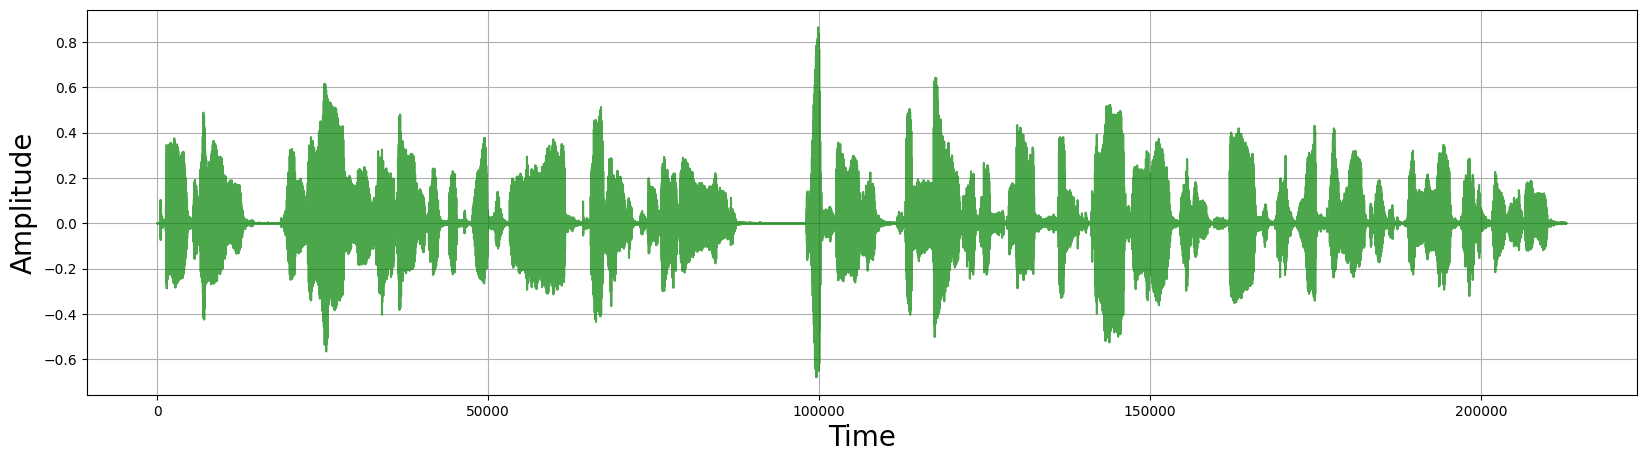

In [ ]:
visualize_audio(wav)

# Gaussian Noise

A very simple augmentation that appears in various areas of machine learning.

In [ ]:
from torch import distributions

In [ ]:
noiser = distributions.Normal(0, 0.05)

In [ ]:
augumented_wav_1 = wav + noiser.sample(wav.size())

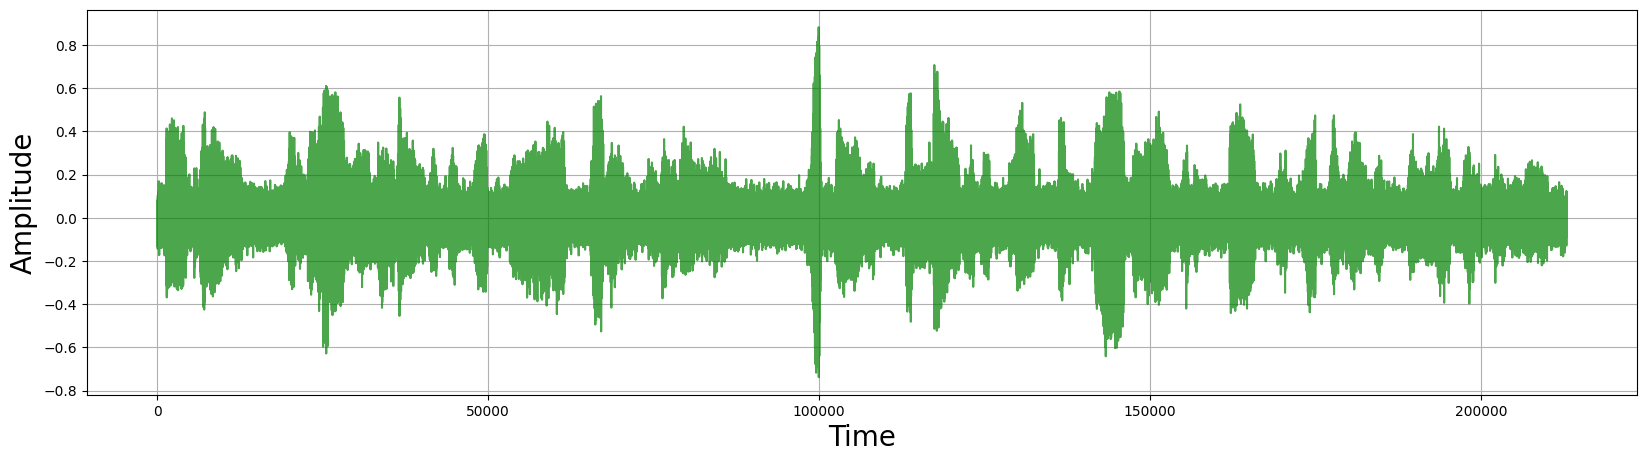

In [ ]:
visualize_audio(augumented_wav_1)

Signal-To-Noise (SNR) ratio:

$$
\text{SNR} = \frac{P_{\text{signal}}}{P_{noise}}
$$

In dB:

$$
\text{SNR}_{\text{db}} = 10 \log_{10} \frac{P_{\text{signal}}}{P_{noise}}
$$

If we have a signal $x$, we define power as $\|x\|^2_2$.

The higher the SNR, the less noisy is the audio.

In [ ]:
def add_noise_with_a_given_snr(x, snr):
    p_x = x.norm() ** 2
    p_noise_desired = p_x / (10 ** (snr / 10))

    noise = torch.randn_like(x)

    p_noise = noise.norm() ** 2

    scale = (p_noise_desired / p_noise) ** 0.5
    return x + scale * noise

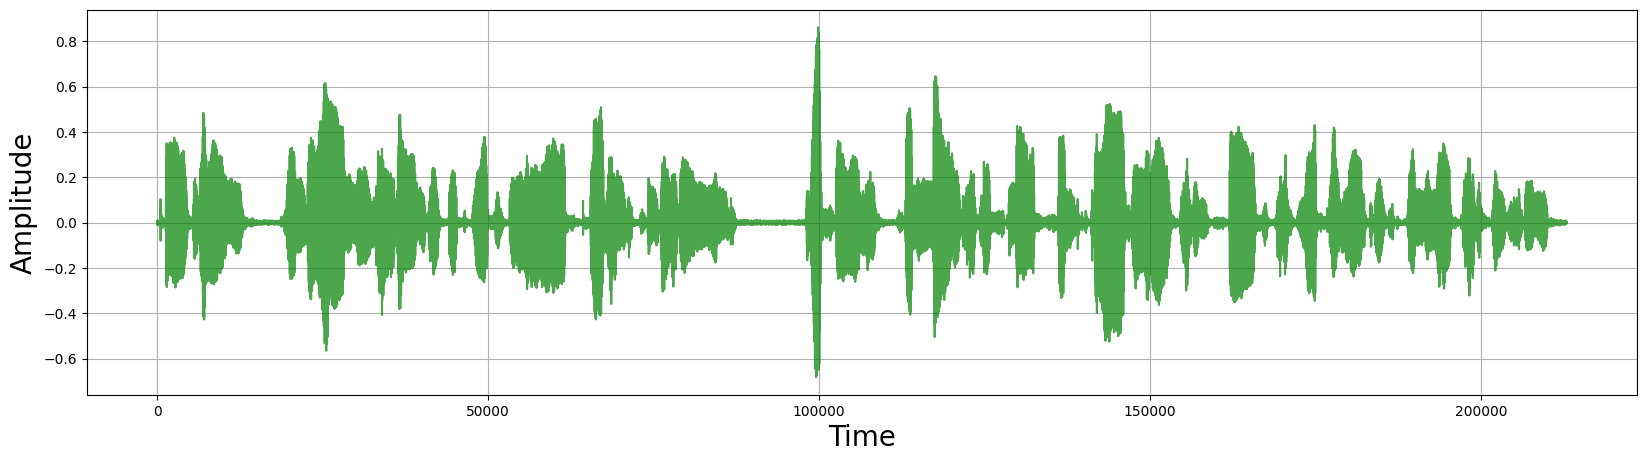

In [ ]:
visualize_audio(add_noise_with_a_given_snr(wav, 30))

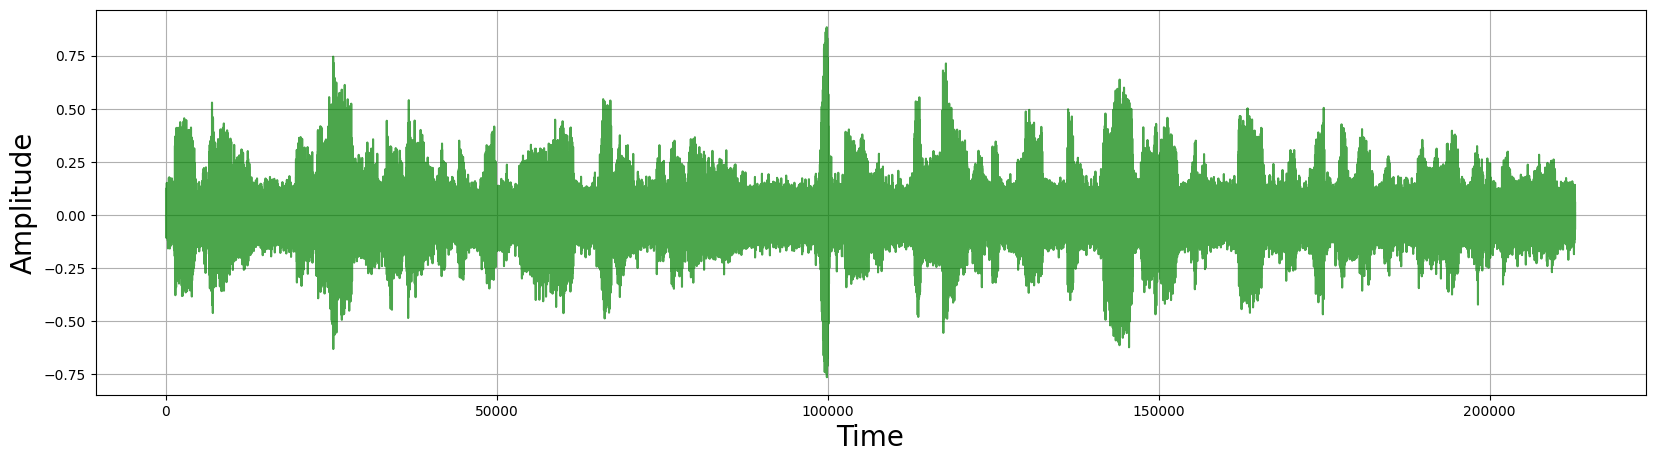

In [ ]:
visualize_audio(add_noise_with_a_given_snr(wav, 5))

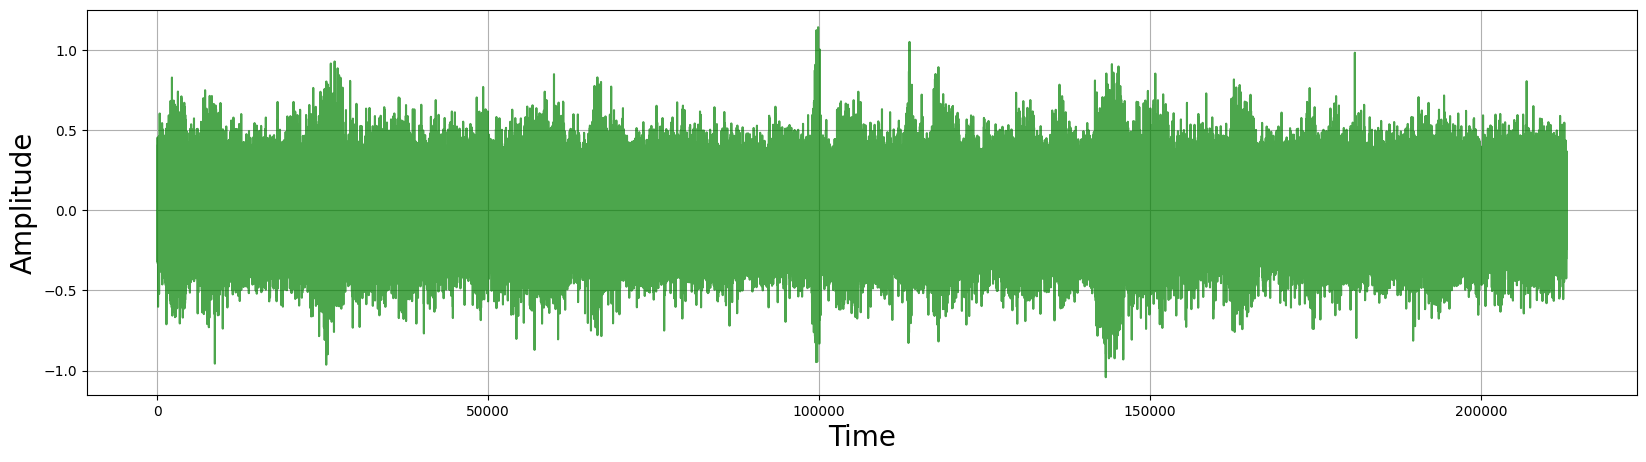

ValueError: Audio data must be between -1 and 1 when normalize=False.

In [ ]:
visualize_audio(add_noise_with_a_given_snr(wav, -5))

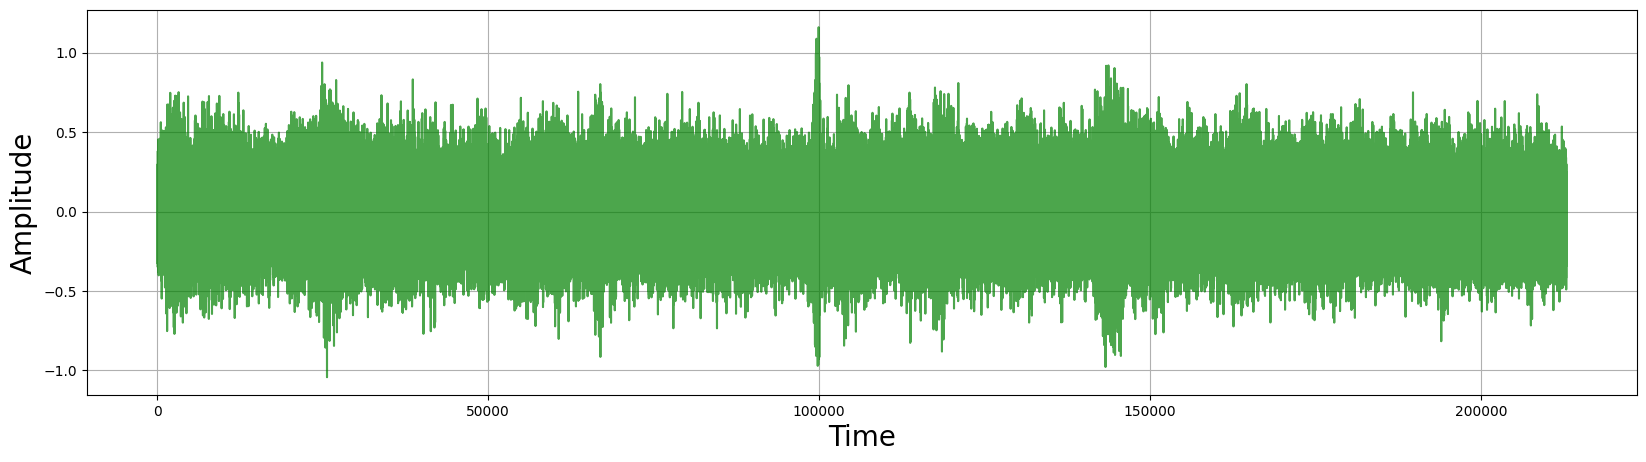

In [ ]:
visualize_audio(add_noise_with_a_given_snr(wav, -5), normalize=True)

# Time Stretching

Naive approach:

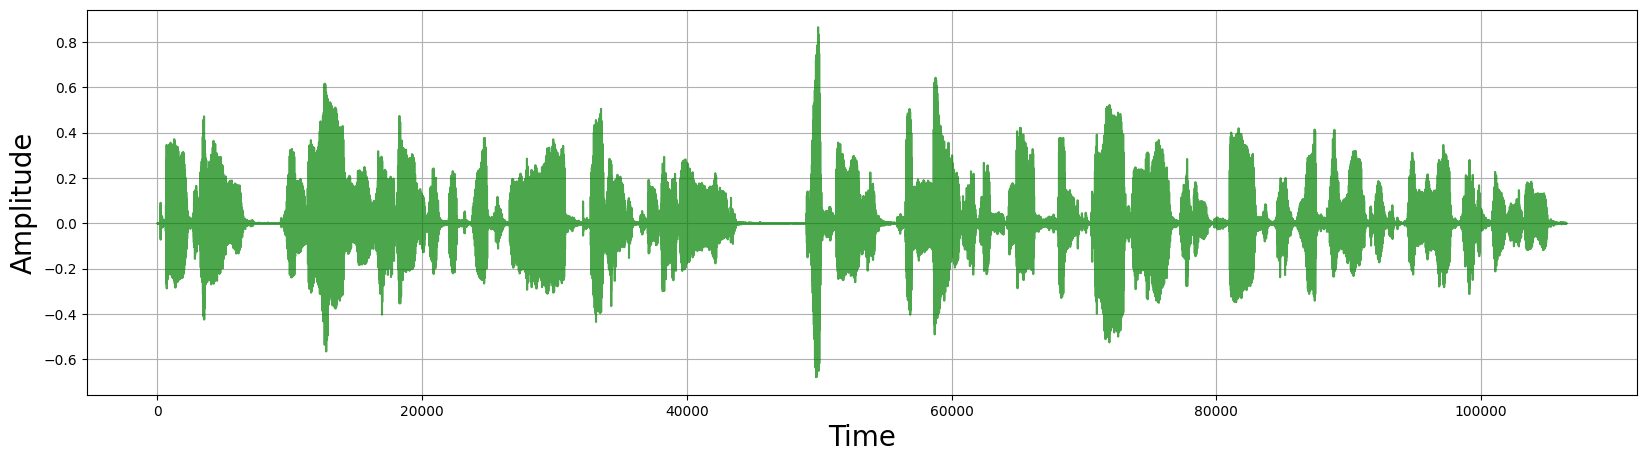

In [ ]:
simple_stretch = wav[:, ::2]
visualize_audio(simple_stretch)

The issue is that we keep the Sample Rate the same.

Imagine x is a sine wav of frequency $f$. If you keep the sample rate the same but take every second point, you use twice as many points within the same time period. So the frequency of your sine wav becomes $2 * f$. This changes the pitch, not only the time.


Is we use the halfed sample rate, we will return back to "normal" with some distorted frequencies

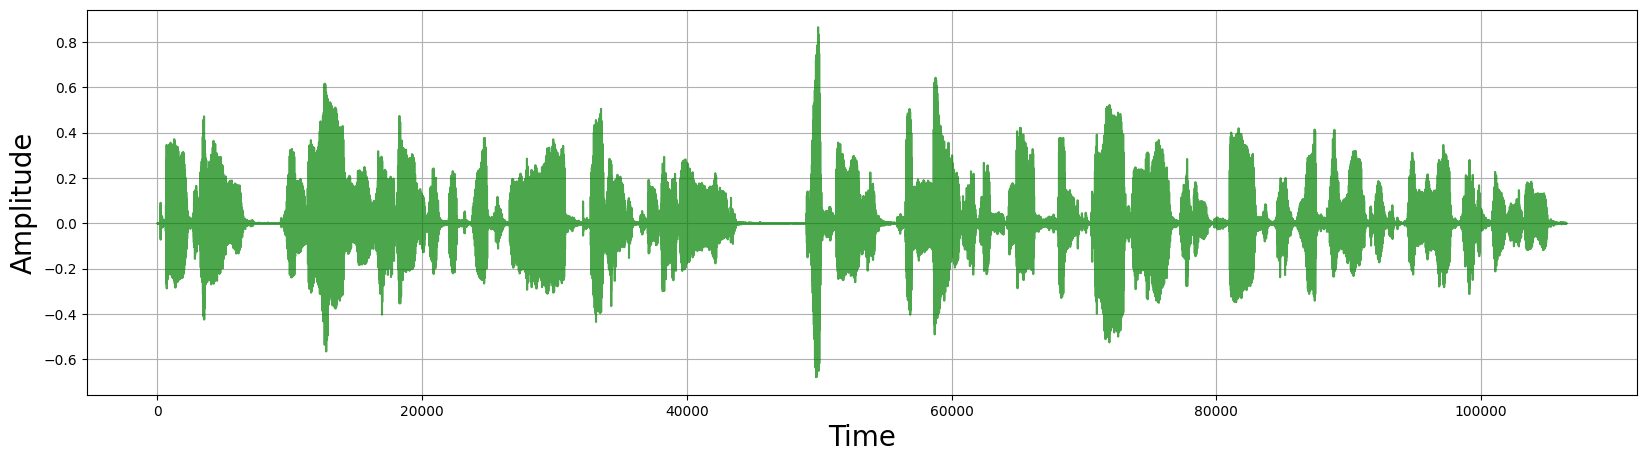

In [ ]:
visualize_audio(simple_stretch, sr=sr/2)

Advanced approach:

This augmentation speeds up or slows down the speed of speech. For more information, visit https://www.dafx.de/paper-archive/2000/pdf/Bernardini.pdf.
There are two ways to do `Time Stretching`:

1) Use `librosa.effects.time_stretch` from `librosa` which works with `wav`s

2) Use `torchaudio.transforms.TimeStretch` from `torchaudio` which works with `spectrogram`s.
In this case, we additionally need to use STFT and iSTFT (inverse STFT)

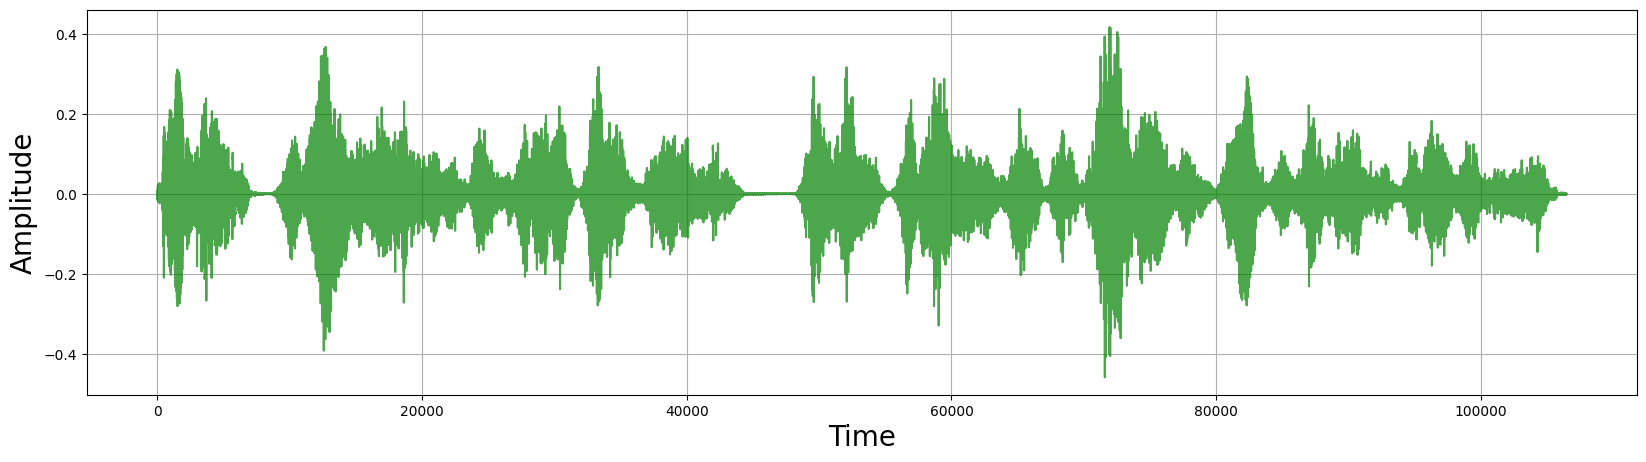

In [ ]:
augumented_wav_2 = librosa.effects.time_stretch(wav.numpy().squeeze(), rate=2.0)
augumented_wav_2 = torch.from_numpy(augumented_wav_2)
visualize_audio(augumented_wav_2)

# Pitch Shifting

This augmentation changes the pitch of voice. For example, it makes the voice more "heavy". Similarly, for more information, visit https://www.dafx.de/paper-archive/2000/pdf/Bernardini.pdf.

In [ ]:
augumented_wav_3 = librosa.effects.pitch_shift(wav.numpy().squeeze(), sr=sr, n_steps=-5)
augumented_wav_3 = torch.from_numpy(augumented_wav_3)

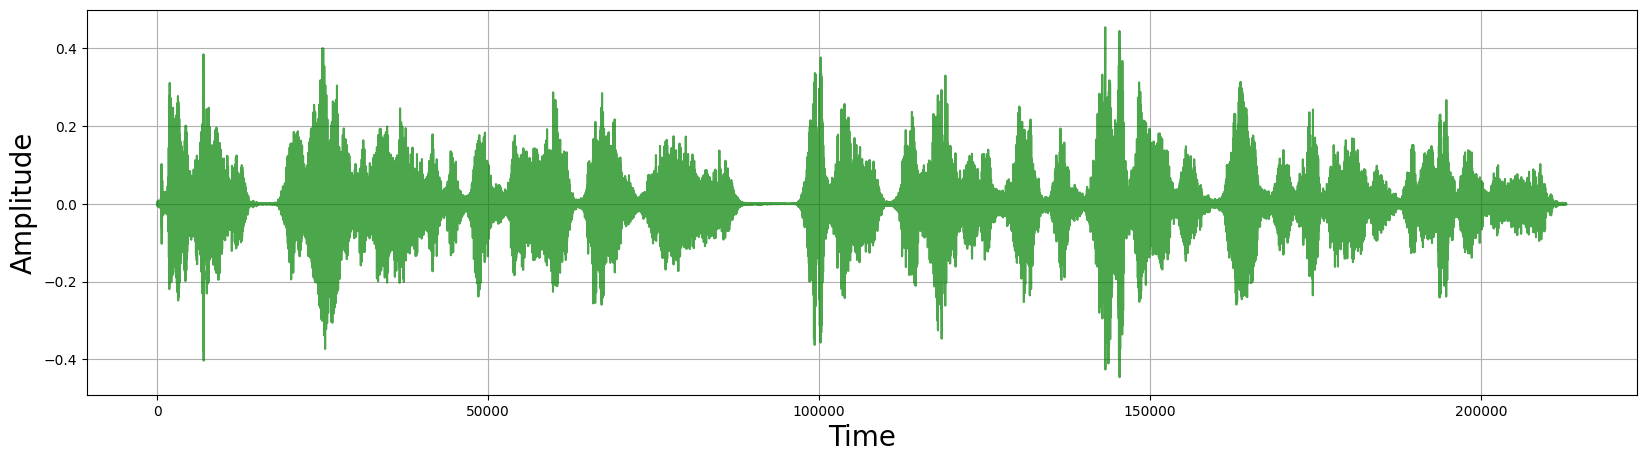

In [ ]:
visualize_audio(augumented_wav_3)

# Volume

This augmentation changes level of volume. It seems like simple augmentation but in some cases it could help :)

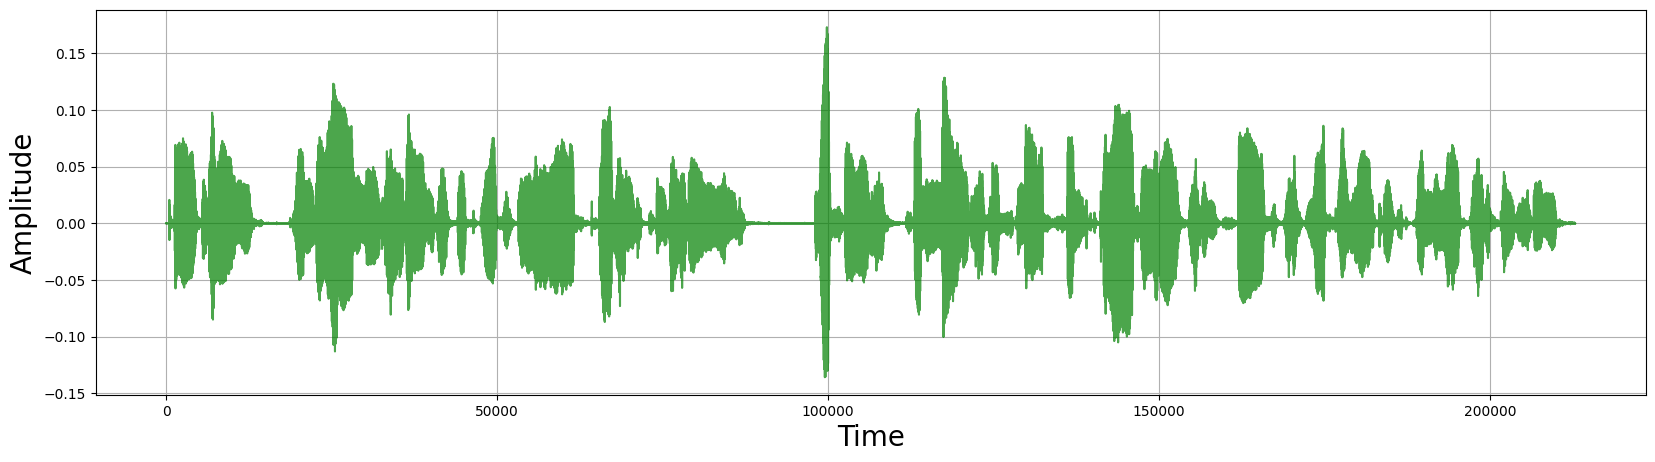

In [ ]:
voler = torchaudio.transforms.Vol(gain=.2, gain_type='amplitude')
augumented_wav_4 = voler(wav)
visualize_audio(augumented_wav_4)

# Room Impulse Response

This augmentation convolves an audio signal with an impulse response. As result, we simulate new enviroment acoustic on given audio.

It may be a little bit trickly, so feel free to learn more about it:

    1) https://www.acousticalsurfaces.com/acoustic_IOI/reverberation.htm
    2) https://www.sonic-shield.com/echo-vs-reverberation
    3) https://en.wikipedia.org/wiki/Convolution_reverb
    4) https://danielpovey.com/files/2017_icassp_reverberation.pdf

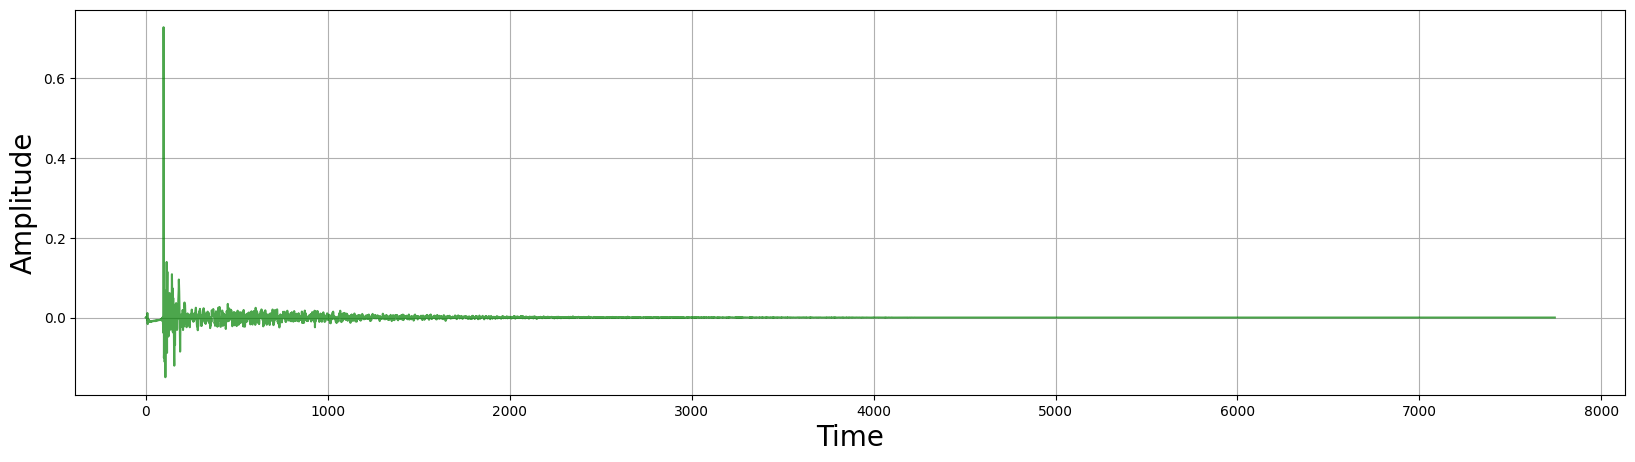

In [ ]:
rir, rir_sr = torchaudio.load('h001_Bedroom_65.wav')
visualize_audio(rir, rir_sr)

In [ ]:
def simulate(audio: torch.Tensor, rir: torch.Tensor):
    left_pad = right_pad = rir.shape[-1] - 1

    # Since torch.conv do cross-correlation (not convolution) we need to flip kernel
    flipped_rir = rir.squeeze().flip(0)

    audio = F.pad(audio, [left_pad, right_pad]).view(1, 1, -1)
    convolved_audio = torch.conv1d(audio, flipped_rir.view(1, 1, -1)) \
        .squeeze()

    # peak normalization
    if convolved_audio.abs().max() > 1:
        convolved_audio /= convolved_audio.abs().max()

    return convolved_audio

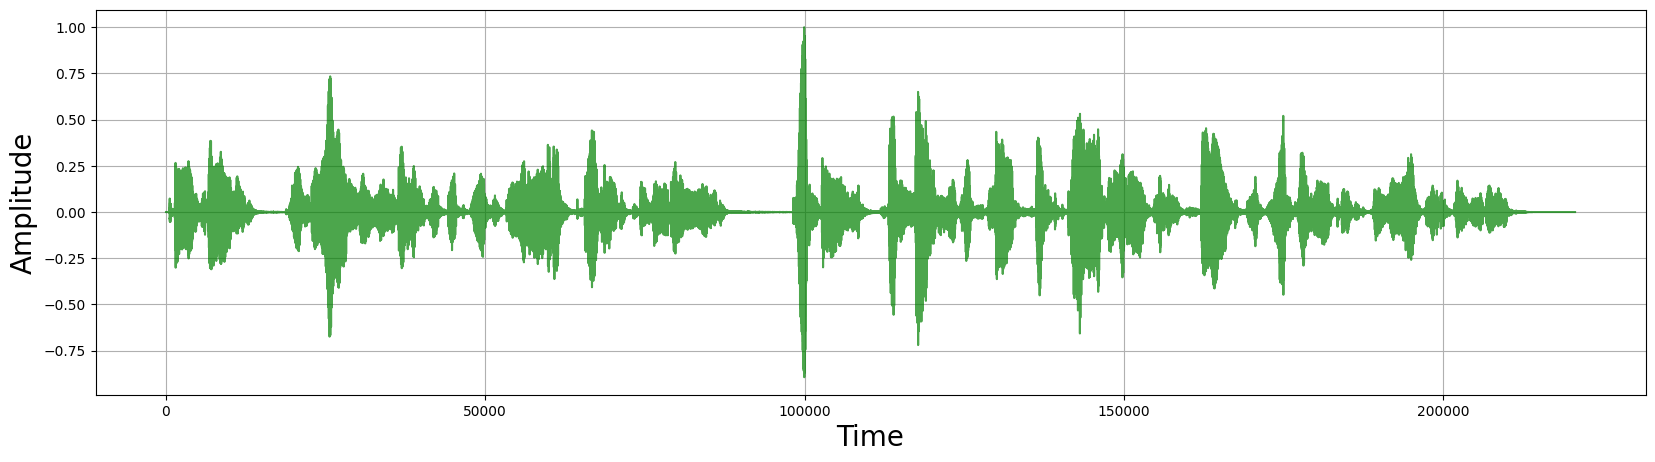

In [ ]:
augumented_wav_5 = simulate(wav, rir)
visualize_audio(augumented_wav_5)

# Add noise audio on background

Let's imagine that we have a lot of samples of noises. For example, sound of street, car, talk an so on. Then we would like to add such noise to the background so that the model (for example, ASR) would be more robust to them.

There is a rule of thumb on how to properly add noise to the background:

    1) https://medium.com/analytics-vidhya/adding-noise-to-audio-clips-5d8cee24ccb8
    2) https://arxiv.org/pdf/1808.00563.pdf (3.1 chapter)

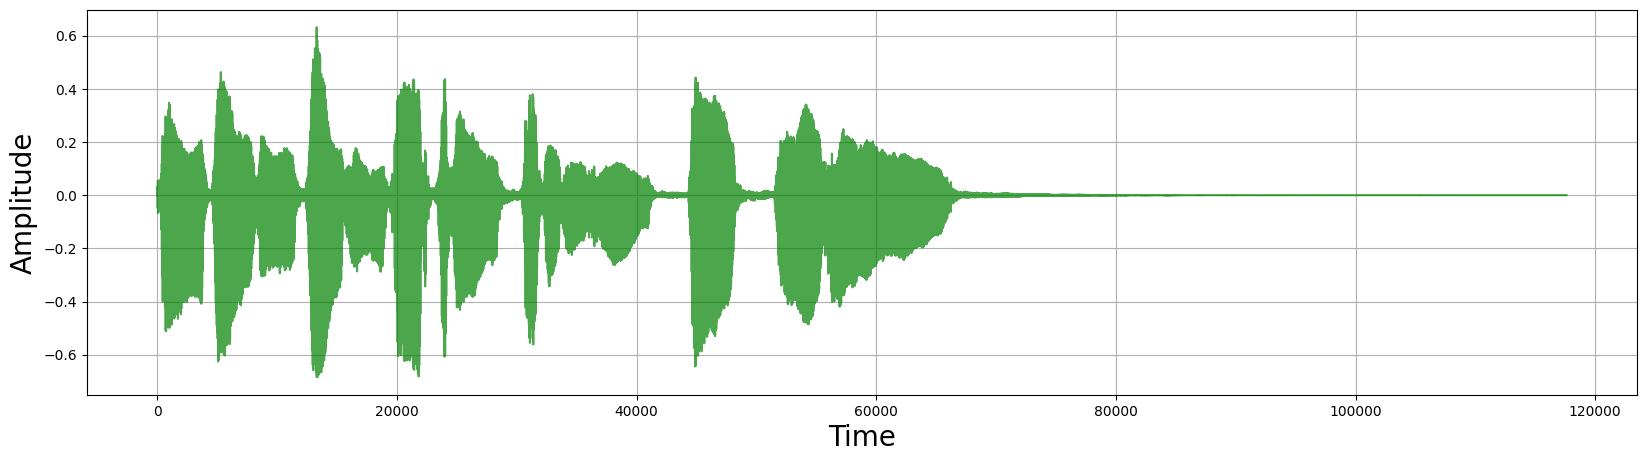

In [ ]:
filename = librosa.ex('trumpet')
y, sr = librosa.load(filename)

noise = y

visualize_audio(torch.from_numpy(noise))

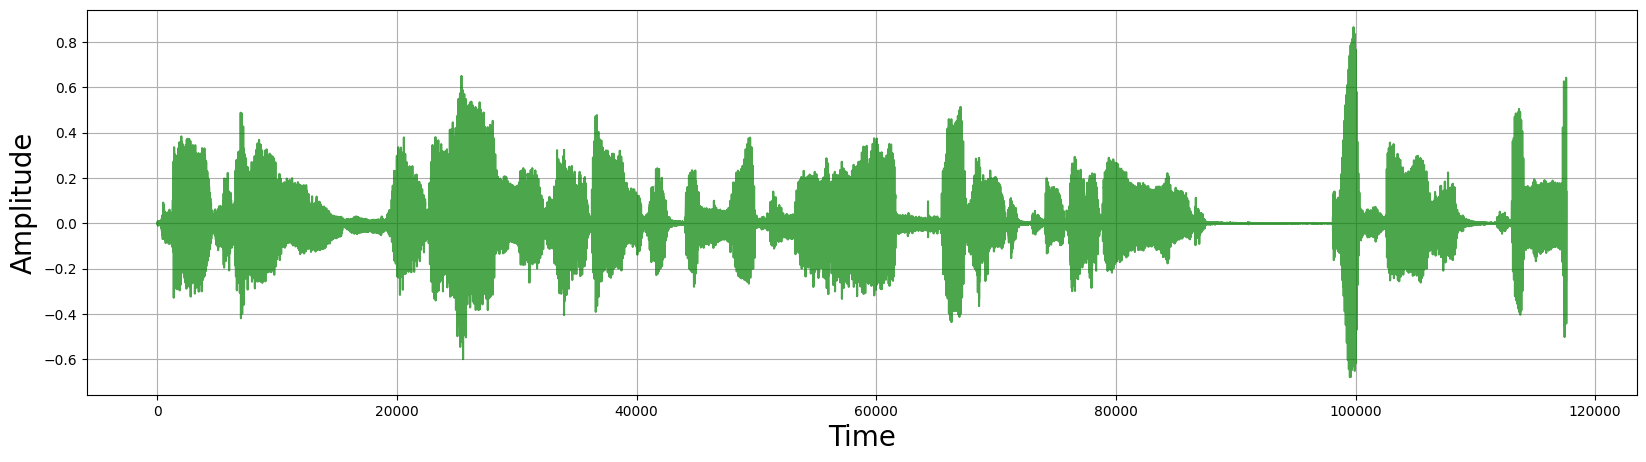

In [ ]:
noize_level = torch.Tensor([20])  # [0, 40]

noize_energy = torch.norm(torch.from_numpy(noise))
audio_energy = torch.norm(wav)

alpha = (audio_energy / noize_energy) * torch.pow(10, -noize_level / 20)

clipped_wav = wav[..., :noise.shape[0]]

augumented_wav_6 = clipped_wav + alpha * torch.from_numpy(noise)

# In some cases the resulting sound may go beyond [-1, 1]
# So, clamp it :)
augumented_wav_6 = torch.clamp(augumented_wav_6, -1, 1)

visualize_audio(augumented_wav_6)

# SpecAug (Time/Freq masking, Cutout)

As we already know, main type of “features" in speech processing is (Mel)Spectrogram. From a practical point of view Spectrogram is image, so we сould apply some ideas from Computer Vision. `SpecAug` motivation come from it.

For more details, please, visit: https://arxiv.org/pdf/1904.08779.pdf

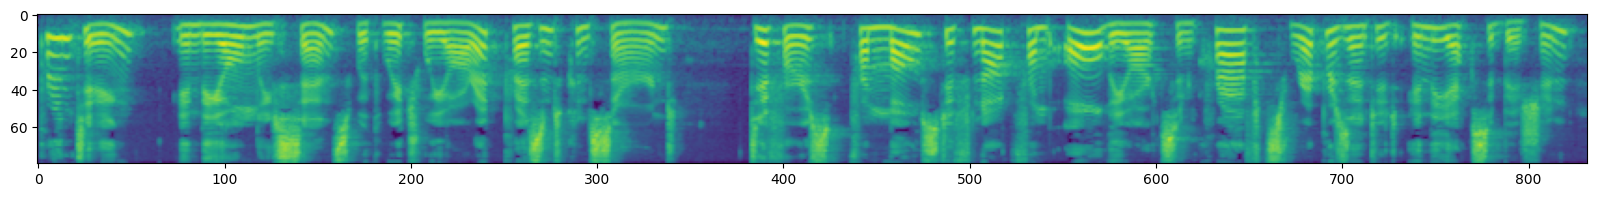

In [ ]:
mel_spectrogramer = torchaudio.transforms.MelSpectrogram(
    sample_rate=22050,
    n_fft=1024,
    win_length=1024,
    hop_length=256,
    n_mels=80,
)

mel_spectrogram = mel_spectrogramer(wav)
log_mel_spectrogram = torch.log(mel_spectrogram).squeeze()
plt.figure(figsize=(20, 5))
plt.imshow(log_mel_spectrogram)
plt.show()

`torchaudio.transforms.FrequencyMasking` add horizontal strip and `torchaudio.transforms.TimeMasking` add vertical strip.

Note that this is one way to implement SpecAug. In practice, you may encounter different implementations.

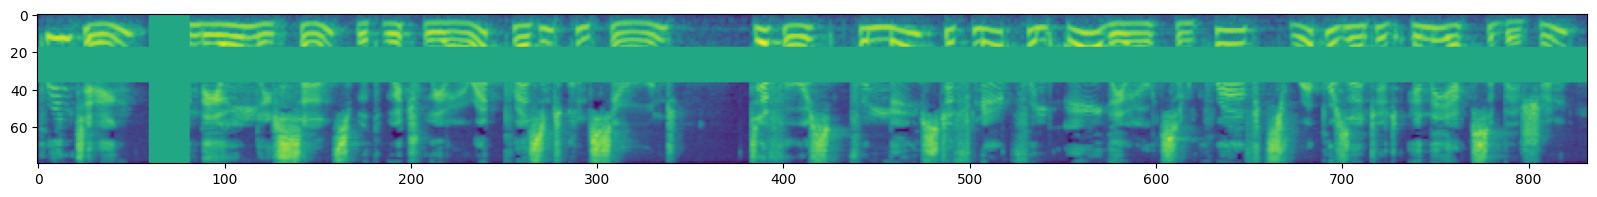

In [ ]:
specaug = nn.Sequential(
    torchaudio.transforms.FrequencyMasking(20),
    torchaudio.transforms.TimeMasking(100),
)

augumented_log_mel_spectrogram = specaug(log_mel_spectrogram)

plt.figure(figsize=(20, 5))
plt.imshow(augumented_log_mel_spectrogram)
plt.show()

# CTC

In [ ]:
import pickle
import torch


# Load precomputed CTC output
with open('mystery_records.pickle', 'rb') as f:
    batch = pickle.load(f)

# log probabilities of softmax layers [batch_size, T, vocab_size]
log_probs = batch["log_probs"]

# Dictionary with index to character mapping
ind2char = batch["ind2char"]

# Index of special EMPTY token
EMPTY_TOK = '^'
EMPTY_IND = 0

In [ ]:
def ctc_decode(inds, ind2char):
    # your code here
    raise NotImplementedError

for i, rec in enumerate(log_probs):
    text = ctc_decode(rec.argmax(-1).numpy(), ind2char)
    print(f"{i}) {text}")



## Computing WER and CER

Given strings $A$ and $B$ with lengths $m$ and $n$:

Define a matrix $D$ of size $(m+1) \times (n+1)$:

$$
D[i][0] = i
$$

$$
D[0][j] = j
$$

Recurrence:

$$
D[i][j] =
\begin{cases}
D[i-1][j-1], & \text{if } A[i] = B[j] \\
1 + \min\left( D[i-1][j],\; D[i][j-1],\; D[i-1][j-1] \right), & \text{otherwise}
\end{cases}
$$

Where:

- $D[i-1][j]$ → deletion  
- $D[i][j-1]$ → insertion  
- $D[i-1][j-1]$ → substitution  

Final distance:

$$
\text{Edit(Levenshtein)Distance}(A, B) = D[m][n]
$$


Implement WER/CER calculation

In [ ]:
# library for fast quick calculation of edit distance
import editdistance

def calc_wer(target_text: str, pred_text: str):
    # your code here
    raise NotImplementedError


def calc_cer(target_text: str, pred_text: str):
    # your code here
    raise NotImplementedError


In [ ]:
import numpy as np

for target, pred, expected_wer, expected_cer in [
    ("if you can not measure it you can not improve it",
     "if you can nt measure t yo can not i",
     0.454, 0.25),
    ("if you cant describe what you are doing as a process you dont know what youre doing",
     "if you cant describe what you are doing as a process you dont know what youre doing",
     0.0, 0.0),
    ("one measurement is worth a thousand expert opinions",
     "one  is worth thousand opinions",
     0.375, 0.392)
]:
    wer = calc_wer(target, pred)
    cer = calc_cer(target, pred)
    assert np.isclose(wer, expected_wer, atol=1e-3), f"true: {target}, pred: {pred}, expected wer {expected_wer} != your wer {wer}"
    assert np.isclose(cer, expected_cer, atol=1e-3), f"true: {target}, pred: {pred}, expected cer {expected_cer} != your cer {cer}"


When WER can be > 1 and when CER can be > than WER?

In [ ]:
# 1) WER > 1.0
# your code here
target, prediction = "<...>" , "<...>"
assert calc_wer(target, prediction) > 1.0

# 2) CER > WER
# your code here
target, prediction = "<...>", "<...>"
assert calc_wer(target, prediction) < calc_cer(target, prediction)


## Beam Search

Implement CTC Beam Search

In [ ]:
# Load precomputed CTC output
with open('lj_batch.pickle', 'rb') as f:
    batch = pickle.load(f)

# log probabilities of softmax layers [batch_size, T, vocab_size]
log_probs = batch["log_probs"]

# Dictionary with index to character mapping
ind2char = batch["ind2char"]

true_texts = batch["text"]

In [ ]:
from collections import defaultdict
from tqdm import tqdm

def ctc_beam_search(probs, beam_size, ind2char):
    # your code here
    raise NotImplementedError

In [ ]:
bs_results = []
for log_probs_line in log_probs:
    bs_results.append(ctc_beam_search(log_probs_line.exp().numpy(), 100, ind2char))

In [ ]:
for i in range(len(true_texts)):
    beam_search_hypos = bs_results[i][:3]
    true_text = true_texts[i]
    argmax_text = ctc_decode(log_probs[i].numpy().argmax(-1), ind2char)
    print("True: ", true_text)
    print(f"Argmax: {argmax_text} --- (CER: {calc_cer(true_text, argmax_text):.3f})")
    for ind, (hypo, score) in enumerate(beam_search_hypos):
        print(f"{ind+1}) '{hypo}' --- (CER: {calc_cer(true_text, hypo):.3f})")
    print('-' * 100)